#Phase 1: Setup & Preparation
##1.1 Environment Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import time
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import (Xception,
                                           EfficientNetB3,
                                           MobileNetV3Large,
                                           DenseNet121,
                                           ResNet50
                                           )
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint,
                                        ReduceLROnPlateau,
                                        CSVLogger,
                                        TensorBoard
                                        )


from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             precision_recall_fscore_support,
                             roc_auc_score,
                             roc_curve,
                             cohen_kappa_score
                             )
from sklearn.preprocessing import label_binarize

from tensorflow.keras import optimizers, layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import seaborn as sns

Set Random Seeds for Reproducibility

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

Global configuration for the experiment

In [ ]:
class Config:

    # Paths

    DATASET_PATH = "/content/drive/MyDrive/Mini projet/processed_dataset/dl_dataset"
    OUTPUT_PATH = "/content/drive/MyDrive/Mini projet/transfer_learning_results"


    # Dataset parameters
    CLASSES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    NUM_CLASSES = 4
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32

    # Training parameters
    EPOCHS_BASELINE = 50
    EPOCHS_FINETUNE = 30
    INITIAL_LR = 0.001
    FINETUNE_LR = 0.0001

    # Model architectures
    MODELS = {
        'Xception': Xception,
        'EfficientNetB3': EfficientNetB3,
        'MobileNetV3Large': MobileNetV3Large,
        'DenseNet121': DenseNet121,
        'ResNet50': ResNet50
    }

config = Config()

# Create output directories
os.makedirs(config.OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(config.OUTPUT_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(config.OUTPUT_PATH, 'logs'), exist_ok=True)
os.makedirs(os.path.join(config.OUTPUT_PATH, 'plots'), exist_ok=True)
os.makedirs(os.path.join(config.OUTPUT_PATH, 'results'), exist_ok=True)

print(f"\n Configuration loaded successfully")
print(f" Output directory: {config.OUTPUT_PATH}")


 Configuration loaded successfully
 Output directory: /content/drive/MyDrive/Mini projet/transfer_learning_results


##1.2 Data Loading & Verification

In [ ]:
# Create generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(config.DATASET_PATH, 'train'),
    target_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_SEED
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(config.DATASET_PATH, 'val'),
    target_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(config.DATASET_PATH, 'test'),
    target_size=config.IMG_SIZE,
    batch_size=config.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")

Found 2800 images belonging to 4 classes.
Found 600 images belonging to 4 classes.
Found 600 images belonging to 4 classes.
Train: 2800, Val: 600, Test: 600


#Phase 2: Baseline Training

1. For each model (Xception, EfficientNetB3, MobileNetV3-Large, DenseNet121, ResNet50):
- Load pre-trained weights (ImageNet)
- Freeze base model layers (transfer learning)
- Add custom classification head:
  - Global Average Pooling
  - Dense layer(s) with dropout
  - Output layer (4 classes, softmax)
- Compile with initial hyperparameters



2. Initial Training Configuration
- **Optimizer**: Adam with initial learning rate (e.g., 0.001)
- **Loss function**: Categorical crossentropy
- **Metrics**: Accuracy, Precision, Recall, F1-Score, AUC
- **Batch size**: 32 (adjustable based on memory)
- **Epochs**: 50 with early stopping
- **Callbacks**:
  - EarlyStopping (patience=10, monitor='val_loss')
  - ModelCheckpoint (save best model)
  - ReduceLROnPlateau (reduce learning rate when plateau)
  - CSVLogger (log training history)

In [ ]:
def build_model(base_model_class, model_name, trainable=False):
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = trainable

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(config.NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, base_model

def compile_model(model, learning_rate=0.001):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')]
    )
    return model

def get_callbacks(model_name, phase='baseline'):
    model_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_{phase}_best.h5')
    log_path = os.path.join(config.OUTPUT_PATH, 'logs', f'{model_name}_{phase}_log.csv')

    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        CSVLogger(log_path)
    ]

In [ ]:
baseline_results = {}

for model_name, model_class in config.MODELS.items():
    print(f"\n{'-'*80}")
    print(f"Training: {model_name} (Baseline)")
    print(f"{'-'*80}")

    model, base_model = build_model(model_class, model_name, trainable=False)
    model = compile_model(model, learning_rate=config.INITIAL_LR)

    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_params:,}")

    start_time = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=config.EPOCHS_BASELINE,
        callbacks=get_callbacks(model_name, 'baseline'),
        verbose=1
    )
    training_time = time.time() - start_time

    print(f" Training completed in {training_time/60:.2f} minutes")

    baseline_results[model_name] = {
        'history': history.history,
        'training_time': training_time,
        'trainable_params': int(trainable_params)
    }

    del model, base_model
    tf.keras.backend.clear_session()


--------------------------------------------------------------------------------
Training: Xception (Baseline)
--------------------------------------------------------------------------------
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable parameters: 557,956
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.5841 - auc: 0.8108 - loss: 0.9903 - precision: 0.7146 - recall: 0.4211 
Epoch 1: val_accuracy improved from -inf to 0.87333, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/Xception_baseline_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 2721s 31s/step - accuracy: 0.5854 - auc: 0.8118 - loss: 0.9878 - precision: 0.7156 - recall: 0.4231 - val_accuracy: 0.8733 - val_auc: 0.9753 - val_loss: 0.3683 - val_precision: 0.8986 - val_recall: 0.8567 - learning_rate: 0.0010
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8403 - auc: 0.9653 - loss: 0.4448 - precision: 0.8794 - recall: 0.8074
Epoch 2: val_accuracy improved from 0.87333 to 0.89333, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/Xception_baseline_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 590ms/step - accuracy: 0.8403 - auc: 0.9653 - loss: 0.4448 - precision: 0.8794 - recall: 0.8074 - val_accuracy: 0.8933 - val_auc: 0.9823 - val_loss: 0.3103 - val_precision: 0.9159 - val_recall: 0.8717 - learning_rate: 0.0010
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.8612 - auc: 0.9743 - loss: 0.3850 - precision: 0.8836 - recall: 0.8321
Epoch 3: val_accuracy did not improve from 0.89333
88/88 ━━━━━━━━━━━━━━━━━━━━ 79s 552ms/step - accuracy: 0.8612 - auc: 0.9743 - loss: 0.3850 - precision: 0.8836 - recall: 0.8322 - val_accuracy: 0.8933 - val_auc: 0.9821 - val_loss: 0.3067 - val_precision: 0.9029 - val_recall: 0.8683 - learning_rate: 0.0010
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8820 - auc: 0.9780 - loss: 0.3499 - precision: 0.9046 - recall: 0.8509
Epoch 4: val_accuracy improved from 0.89333 to 0.91167, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/Xceptio

88/88 ━━━━━━━━━━━━━━━━━━━━ 49s 562ms/step - accuracy: 0.8820 - auc: 0.9780 - loss: 0.3498 - precision: 0.9046 - recall: 0.8510 - val_accuracy: 0.9117 - val_auc: 0.9861 - val_loss: 0.2751 - val_precision: 0.9293 - val_recall: 0.8983 - learning_rate: 0.0010
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8821 - auc: 0.9807 - loss: 0.3240 - precision: 0.9065 - recall: 0.8589
Epoch 5: val_accuracy improved from 0.91167 to 0.91833, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/Xception_baseline_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 581ms/step - accuracy: 0.8823 - auc: 0.9807 - loss: 0.3237 - precision: 0.9065 - recall: 0.8591 - val_accuracy: 0.9183 - val_auc: 0.9896 - val_loss: 0.2254 - val_precision: 0.9364 - val_recall: 0.9083 - learning_rate: 0.0010
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8990 - auc: 0.9848 - loss: 0.2814 - precision: 0.9177 - recall: 0.8872
Epoch 6: val_accuracy did not improve from 0.91833
88/88 ━━━━━━━━━━━━━━━━━━━━ 79s 549ms/step - accuracy: 0.8990 - auc: 0.9848 - loss: 0.2815 - precision: 0.9177 - recall: 0.8871 - val_accuracy: 0.9133 - val_auc: 0.9904 - val_loss: 0.2320 - val_precision: 0.9245 - val_recall: 0.8983 - learning_rate: 0.0010
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.8938 - auc: 0.9813 - loss: 0.3118 - precision: 0.9118 - recall: 0.8777
Epoch 7: val_accuracy did not improve from 0.91833
88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 543ms/step - accuracy: 0.8939 - auc: 0.9813 - loss: 0.3115 - precision: 0.9118 - 

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 50s 573ms/step - accuracy: 0.4644 - auc: 0.7531 - loss: 1.1445 - precision: 0.7283 - recall: 0.1484 - val_accuracy: 0.5517 - val_auc: 0.8025 - val_loss: 1.0832 - val_precision: 0.7557 - val_recall: 0.1650 - learning_rate: 5.0000e-04
Epoch 39/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.4847 - auc: 0.7452 - loss: 1.1625 - precision: 0.7280 - recall: 0.1392
Epoch 39: val_accuracy improved from 0.55167 to 0.57500, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/ResNet50_baseline_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 581ms/step - accuracy: 0.4848 - auc: 0.7453 - loss: 1.1623 - precision: 0.7284 - recall: 0.1393 - val_accuracy: 0.5750 - val_auc: 0.8079 - val_loss: 1.0788 - val_precision: 0.7638 - val_recall: 0.1617 - learning_rate: 5.0000e-04
Epoch 40/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.4753 - auc: 0.7630 - loss: 1.1335 - precision: 0.7499 - recall: 0.1605
Epoch 40: val_accuracy did not improve from 0.57500
88/88 ━━━━━━━━━━━━━━━━━━━━ 49s 559ms/step - accuracy: 0.4754 - auc: 0.7630 - loss: 1.1335 - precision: 0.7499 - recall: 0.1604 - val_accuracy: 0.5433 - val_auc: 0.7884 - val_loss: 1.1054 - val_precision: 0.7538 - val_recall: 0.1633 - learning_rate: 5.0000e-04
Epoch 41/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.4551 - auc: 0.7498 - loss: 1.1452 - precision: 0.7044 - recall: 0.1606
Epoch 41: val_accuracy did not improve from 0.57500
88/88 ━━━━━━━━━━━━━━━━━━━━ 50s 568ms/step - accuracy: 0.4554 - auc: 0.7499 - loss: 1.1451 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 595ms/step - accuracy: 0.4878 - auc: 0.7573 - loss: 1.1362 - precision: 0.7011 - recall: 0.1642 - val_accuracy: 0.5767 - val_auc: 0.8172 - val_loss: 1.0669 - val_precision: 0.7886 - val_recall: 0.1617 - learning_rate: 5.0000e-04
Epoch 47/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5196 - auc: 0.7788 - loss: 1.0976 - precision: 0.7983 - recall: 0.2050
Epoch 47: val_accuracy improved from 0.57667 to 0.59167, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/models/ResNet50_baseline_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 591ms/step - accuracy: 0.5194 - auc: 0.7787 - loss: 1.0979 - precision: 0.7979 - recall: 0.2049 - val_accuracy: 0.5917 - val_auc: 0.8110 - val_loss: 1.0890 - val_precision: 0.7851 - val_recall: 0.1583 - learning_rate: 5.0000e-04
Epoch 48/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.4831 - auc: 0.7392 - loss: 1.1655 - precision: 0.7120 - recall: 0.1854
Epoch 48: val_accuracy did not improve from 0.59167
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 589ms/step - accuracy: 0.4831 - auc: 0.7393 - loss: 1.1653 - precision: 0.7119 - recall: 0.1855 - val_accuracy: 0.5817 - val_auc: 0.8206 - val_loss: 1.0697 - val_precision: 0.7920 - val_recall: 0.1650 - learning_rate: 5.0000e-04
Epoch 49/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.4925 - auc: 0.7676 - loss: 1.1100 - precision: 0.7919 - recall: 0.2065
Epoch 49: val_accuracy improved from 0.59167 to 0.62167, saving model to /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/transfer_learning_results/mo

88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 608ms/step - accuracy: 0.4924 - auc: 0.7675 - loss: 1.1101 - precision: 0.7915 - recall: 0.2064 - val_accuracy: 0.6217 - val_auc: 0.8344 - val_loss: 1.0272 - val_precision: 0.7836 - val_recall: 0.2233 - learning_rate: 5.0000e-04
Epoch 50/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.4929 - auc: 0.7637 - loss: 1.1244 - precision: 0.7120 - recall: 0.2030
Epoch 50: val_accuracy did not improve from 0.62167
88/88 ━━━━━━━━━━━━━━━━━━━━ 50s 571ms/step - accuracy: 0.4929 - auc: 0.7637 - loss: 1.1243 - precision: 0.7121 - recall: 0.2031 - val_accuracy: 0.6100 - val_auc: 0.8288 - val_loss: 1.0419 - val_precision: 0.7801 - val_recall: 0.1833 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 49.
 Training completed in 42.81 minutes


#Phase 3: Fine-Tuning


##### **3.1 Selective Layer Unfreezing**
For each baseline model:
- Unfreeze last N layers of base model:
  - Xception: Last 30 layers
  - EfficientNetB3: Last 40 layers
  - MobileNetV3: Last 20 layers
  - DenseNet121: Last dense block
  - ResNet50: Last residual block

##### **3.2 Fine-Tuning Configuration**
- **Lower learning rate**: 0.0001 or 0.00001
- **Optimizer**: Adam or SGD with momentum
- **Epochs**: 30-50 additional epochs
- **Same callbacks** as baseline

##### **3.3 Fine-Tuning Execution**
- Load best baseline weights
- Continue training with unfrozen layers
- Monitor for overfitting
- Save fine-tuned models


In [ ]:
UNFREEZE_CONFIG = {
    'Xception': -30,
    'EfficientNetB3': -40,
    'MobileNetV3Large': -20,
    'DenseNet121': -50,
    'ResNet50': -30
}

finetuned_results = {}

for model_name, model_class in config.MODELS.items():
    print(f"\n{'='*80}")
    print(f"Fine-tuning: {model_name}")
    print(f"{'='*80}")

    baseline_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_baseline_best.h5')

    model, base_model = build_model(model_class, model_name, trainable=False)
    model.load_weights(baseline_path)

    base_model.trainable = True
    unfreeze_from = UNFREEZE_CONFIG[model_name]
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"Trainable parameters: {trainable_params:,}")

    model = compile_model(model, learning_rate=config.FINETUNE_LR)

    start_time = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=config.EPOCHS_FINETUNE,
        callbacks=get_callbacks(model_name, 'finetuned'),
        verbose=1
    )
    finetuning_time = time.time() - start_time

    print(f" Fine-tuning completed in {finetuning_time/60:.2f} minutes")

    finetuned_results[model_name] = {
        'history': history.history,
        'finetuning_time': finetuning_time,
        'trainable_params': int(trainable_params)
    }

    del model, base_model
    tf.keras.backend.clear_session()


Fine-tuning: Xception
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Trainable parameters: 9,498,308
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.8537 - auc: 0.9652 - loss: 0.4261 - precision: 0.8781 - recall: 0.8238 
Epoch 1: val_accuracy improved from -inf to 0.86833, saving model to /content/drive/MyDrive/Mini projet/transfer_learning_results/models/Xception_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 2344s 26s/step - accuracy: 0.8543 - auc: 0.9654 - loss: 0.4246 - precision: 0.8786 - recall: 0.8245 - val_accuracy: 0.8683 - val_auc: 0.9714 - val_loss: 0.4684 - val_precision: 0.8744 - val_recall: 0.8583 - learning_rate: 1.0000e-04
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9519 - auc: 0.9963 - loss: 0.1310 - precision: 0.9617 - recall: 0.9461
Epoch 2: val_accuracy improved from 0.86833 to 0.97833, saving model to /content/drive/MyDrive/Mini projet/transfer_learning_results/models/Xception_finetuned_best.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 653ms/step - accuracy: 0.9520 - auc: 0.9964 - loss: 0.1309 - precision: 0.9618 - recall: 0.9461 - val_accuracy: 0.9783 - val_auc: 0.9980 - val_loss: 0.0785 - val_precision: 0.9832 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9741 - auc: 0.9975 - loss: 0.0861 - precision: 0.9778 - recall: 0.9686
Epoch 3: val_accuracy did not improve from 0.97833
88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 647ms/step - accuracy: 0.9741 - auc: 0.9975 - loss: 0.0860 - precision: 0.9778 - recall: 0.9686 - val_accuracy: 0.9733 - val_auc: 0.9968 - val_loss: 0.0909 - val_precision: 0.9766 - val_recall: 0.9733 - learning_rate: 1.0000e-04
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.9725 - auc: 0.9973 - loss: 0.0790 - precision: 0.9779 - recall: 0.9691
Epoch 4: val_accuracy did not improve from 0.97833
88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 574ms/step - accuracy: 0.9726 - auc: 0.9973 - loss: 0.0790 - precision: 0

88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 607ms/step - accuracy: 0.9898 - auc: 0.9997 - loss: 0.0332 - precision: 0.9922 - recall: 0.9883 - val_accuracy: 0.9817 - val_auc: 0.9964 - val_loss: 0.0680 - val_precision: 0.9833 - val_recall: 0.9817 - learning_rate: 1.0000e-04
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9938 - auc: 0.9993 - loss: 0.0251 - precision: 0.9940 - recall: 0.9938
Epoch 11: val_accuracy did not improve from 0.98167
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 618ms/step - accuracy: 0.9938 - auc: 0.9993 - loss: 0.0252 - precision: 0.9940 - recall: 0.9938 - val_accuracy: 0.9717 - val_auc: 0.9960 - val_loss: 0.1057 - val_precision: 0.9749 - val_recall: 0.9717 - learning_rate: 1.0000e-04
Epoch 12/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.9955 - auc: 0.9993 - loss: 0.0217 - precision: 0.9955 - recall: 0.9940
Epoch 12: val_accuracy did not improve from 0.98167
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 590ms/step - accuracy: 0.9955 - auc: 0.9993 - loss: 0.0217 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 617ms/step - accuracy: 0.9908 - auc: 0.9983 - loss: 0.0389 - precision: 0.9912 - recall: 0.9903 - val_accuracy: 0.9883 - val_auc: 0.9978 - val_loss: 0.0525 - val_precision: 0.9899 - val_recall: 0.9850 - learning_rate: 1.0000e-04
Epoch 15/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9987 - auc: 1.0000 - loss: 0.0071 - precision: 0.9987 - recall: 0.9983
Epoch 15: val_accuracy did not improve from 0.98833
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 621ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0072 - precision: 0.9986 - recall: 0.9982 - val_accuracy: 0.9700 - val_auc: 0.9949 - val_loss: 0.1360 - val_precision: 0.9700 - val_recall: 0.9700 - learning_rate: 1.0000e-04
Epoch 16/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9964 - auc: 0.9999 - loss: 0.0139 - precision: 0.9968 - recall: 0.9962
Epoch 16: val_accuracy did not improve from 0.98833
88/88 ━━━━━━━━━━━━━━━━━━━━ 78s 575ms/step - accuracy: 0.9964 - auc: 0.9999 - loss: 0.0140 - precisio

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 57s 647ms/step - accuracy: 0.7413 - auc: 0.9177 - loss: 0.7012 - precision: 0.7973 - recall: 0.6477 - val_accuracy: 0.7783 - val_auc: 0.9408 - val_loss: 0.5932 - val_precision: 0.8347 - val_recall: 0.6983 - learning_rate: 1.0000e-04
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.7534 - auc: 0.9259 - loss: 0.6627 - precision: 0.8067 - recall: 0.6720
Epoch 10: val_accuracy did not improve from 0.77833
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 607ms/step - accuracy: 0.7534 - auc: 0.9259 - loss: 0.6628 - precision: 0.8068 - recall: 0.6720 - val_accuracy: 0.4433 - val_auc: 0.7545 - val_loss: 2.0544 - val_precision: 0.4560 - val_recall: 0.4317 - learning_rate: 1.0000e-04
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.7426 - auc: 0.9168 - loss: 0.7083 - precision: 0.8014 - recall: 0.6434
Epoch 11: val_accuracy did not improve from 0.77833
88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 549ms/step - accuracy: 0.7428 - auc: 0.9169 - loss: 0.7079 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 59s 674ms/step - accuracy: 0.7954 - auc: 0.9427 - loss: 0.5803 - precision: 0.8349 - recall: 0.7276 - val_accuracy: 0.7950 - val_auc: 0.9520 - val_loss: 0.5311 - val_precision: 0.8292 - val_recall: 0.7283 - learning_rate: 5.0000e-05
Epoch 16/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.7998 - auc: 0.9500 - loss: 0.5404 - precision: 0.8520 - recall: 0.7436
Epoch 16: val_accuracy did not improve from 0.79500
88/88 ━━━━━━━━━━━━━━━━━━━━ 55s 627ms/step - accuracy: 0.7998 - auc: 0.9500 - loss: 0.5406 - precision: 0.8520 - recall: 0.7435 - val_accuracy: 0.6367 - val_auc: 0.8784 - val_loss: 0.9059 - val_precision: 0.6845 - val_recall: 0.5967 - learning_rate: 5.0000e-05
Epoch 17/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8007 - auc: 0.9484 - loss: 0.5484 - precision: 0.8485 - recall: 0.7274
Epoch 17: val_accuracy did not improve from 0.79500
88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 551ms/step - accuracy: 0.8007 - auc: 0.9484 - loss: 0.5484 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 703ms/step - accuracy: 0.8067 - auc: 0.9540 - loss: 0.5167 - precision: 0.8594 - recall: 0.7531 - val_accuracy: 0.8000 - val_auc: 0.9547 - val_loss: 0.5142 - val_precision: 0.8470 - val_recall: 0.7383 - learning_rate: 5.0000e-05
Epoch 19/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.8095 - auc: 0.9584 - loss: 0.4927 - precision: 0.8544 - recall: 0.7625
Epoch 19: val_accuracy did not improve from 0.80000
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 610ms/step - accuracy: 0.8095 - auc: 0.9583 - loss: 0.4929 - precision: 0.8544 - recall: 0.7625 - val_accuracy: 0.7967 - val_auc: 0.9513 - val_loss: 0.5448 - val_precision: 0.8236 - val_recall: 0.7550 - learning_rate: 5.0000e-05
Epoch 20/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8182 - auc: 0.9581 - loss: 0.4932 - precision: 0.8596 - recall: 0.7765
Epoch 20: val_accuracy did not improve from 0.80000
88/88 ━━━━━━━━━━━━━━━━━━━━ 50s 571ms/step - accuracy: 0.8181 - auc: 0.9581 - loss: 0.4935 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 58s 660ms/step - accuracy: 0.8399 - auc: 0.9616 - loss: 0.4699 - precision: 0.8740 - recall: 0.7864 - val_accuracy: 0.8233 - val_auc: 0.9581 - val_loss: 0.4949 - val_precision: 0.8719 - val_recall: 0.7717 - learning_rate: 5.0000e-05
Epoch 23/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8290 - auc: 0.9597 - loss: 0.4795 - precision: 0.8677 - recall: 0.7756
Epoch 23: val_accuracy did not improve from 0.82333
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 610ms/step - accuracy: 0.8290 - auc: 0.9597 - loss: 0.4793 - precision: 0.8677 - recall: 0.7758 - val_accuracy: 0.7967 - val_auc: 0.9531 - val_loss: 0.5609 - val_precision: 0.8185 - val_recall: 0.7817 - learning_rate: 5.0000e-05
Epoch 24/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8476 - auc: 0.9644 - loss: 0.4504 - precision: 0.8737 - recall: 0.8062
Epoch 24: val_accuracy did not improve from 0.82333
88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 549ms/step - accuracy: 0.8475 - auc: 0.9643 - loss: 0.4507 - precisio

88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 607ms/step - accuracy: 0.8433 - auc: 0.9678 - loss: 0.4304 - precision: 0.8826 - recall: 0.7940 - val_accuracy: 0.8450 - val_auc: 0.9689 - val_loss: 0.4234 - val_precision: 0.8693 - val_recall: 0.8200 - learning_rate: 5.0000e-05
Epoch 28/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8485 - auc: 0.9676 - loss: 0.4286 - precision: 0.8791 - recall: 0.8112
Epoch 28: val_accuracy did not improve from 0.84500
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 618ms/step - accuracy: 0.8482 - auc: 0.9675 - loss: 0.4291 - precision: 0.8789 - recall: 0.8108 - val_accuracy: 0.7967 - val_auc: 0.9436 - val_loss: 0.5983 - val_precision: 0.8129 - val_recall: 0.7533 - learning_rate: 5.0000e-05
Epoch 29/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8319 - auc: 0.9615 - loss: 0.4688 - precision: 0.8696 - recall: 0.7848
Epoch 29: val_accuracy did not improve from 0.84500
88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 582ms/step - accuracy: 0.8320 - auc: 0.9616 - loss: 0.4687 - precisio

# Phase 4: Hyperparameter Optimization
Selects top 3 models based on validation accuracy

In [ ]:
model_scores = {name: max(data['history']['val_accuracy'])
                for name, data in finetuned_results.items()}
top_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)[:3]
top_model_names = [name for name, _ in top_models]

print(f" Top 3 models selected: {top_model_names}")

In [ ]:
top_model_names = ['Xception']

Top 3 models selected: 'Xception', 'DenseNet121', 'ResNet50'

###1. Bayesian-Inspired Adaptive Search
Generate hyperparameter configurations for optimizing fine-tuned models. Focus on learning rate, optimizer, and light regularization adjustments

In [ ]:
def generate_smart_hp_configs(n_configs=12):

    configs = []

    # Core configurations - focus on learning dynamics
    core_configs = [
        # Conservative fine-tuning continuation
        {'lr': 0.00005, 'optimizer': 'adam', 'l2_reg': 0.0001},
        {'lr': 0.0001, 'optimizer': 'adam', 'l2_reg': 0.0001},

        # Slightly higher learning rate
        {'lr': 0.0002, 'optimizer': 'adam', 'l2_reg': 0.0001},

        # Different regularization strengths
        {'lr': 0.0001, 'optimizer': 'adam', 'l2_reg': 0.00001},
        {'lr': 0.0001, 'optimizer': 'adam', 'l2_reg': 0.001},

        # SGD alternative with momentum
        {'lr': 0.001, 'optimizer': 'sgd', 'momentum': 0.9, 'l2_reg': 0.0001},
    ]

    configs.extend(core_configs)

    # Random exploration
    for _ in range(n_configs - len(core_configs)):
        optimizer_choice = random.choice(['adam', 'adam', 'sgd'])

        if optimizer_choice == 'adam':
            config = {
                'lr': random.choice([0.00005, 0.0001, 0.00015, 0.0002, 0.0005]),
                'optimizer': 'adam',
                'l2_reg': random.choice([0.00001, 0.0001, 0.0005, 0.001])
            }
        else:
            config = {
                'lr': random.choice([0.0005, 0.001, 0.005, 0.01]),
                'optimizer': 'sgd',
                'momentum': random.choice([0.9, 0.95, 0.99]),
                'l2_reg': random.choice([0.00001, 0.0001, 0.001])
            }

        configs.append(config)

    return configs

Generate adaptive configurations

In [ ]:
hp_configs = generate_smart_hp_configs(n_configs=12)

print(f"Generated {len(hp_configs)} hyperparameter configurations")
print("   Strategy: Optimize from fine-tuned weights")
print("   - 6 core configurations (proven ranges)")
print(f"   - {len(hp_configs)-6} random exploration configs")
print("   - Focus: Learning rate, optimizer, L2 regularization")
print("   - Architecture: Preserved from fine-tuned models")

Generated 12 hyperparameter configurations
   Strategy: Optimize from fine-tuned weights
   - 6 core configurations (proven ranges)
   - 6 random exploration configs
   - Focus: Learning rate, optimizer, L2 regularization
   - Architecture: Preserved from fine-tuned models


###load fine-tuned model and apply l2 regularization

Add L2 regularization to dense layers of loaded model
and returns a new model with same weights but added regularization

In [ ]:
def add_l2_regularization_to_model(model, l2_reg):
    # Get the model config
    model_config = model.get_config()

    # Add L2 regularization to dense layers
    for layer_config in model_config['layers']:
        if layer_config['class_name'] == 'Dense':
            if 'kernel_regularizer' not in layer_config['config']:
                layer_config['config']['kernel_regularizer'] = {
                    'class_name': 'L2',
                    'config': {'l2': l2_reg}
                }

    # Reconstruct model
    new_model = keras.Model.from_config(model_config)

    # Copy weights
    for new_layer, old_layer in zip(new_model.layers, model.layers):
        if old_layer.get_weights():
            new_layer.set_weights(old_layer.get_weights())

    return new_model

Compile model with specified optimizer

In [ ]:
def compile_model_with_optimizer(model, hp_config):

    if hp_config['optimizer'] == 'adam':
        optimizer = optimizers.Adam(learning_rate=hp_config['lr'])
    elif hp_config['optimizer'] == 'sgd':
        optimizer = optimizers.SGD(
            learning_rate=hp_config['lr'],
            momentum=hp_config.get('momentum', 0.9),
            nesterov=True
        )
    else:
        optimizer = optimizers.Adam(learning_rate=hp_config['lr'])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')]
    )
    return model

###progressive hp tuning with ranking


In [ ]:
hp_tuning_results = {}

for model_name in top_model_names:
    print(f"\n{'*'*80}")
    print(f"ADVANCED HP TUNING: {model_name}")
    print(f"{'*'*80}")

    model_class = config.MODELS[model_name]

    # Track all configurations and their performance
    all_configs_results = []

    # Stage 1: Quick screening (10 epochs)
    print(f"\n Stage 1: Quick Screening (10 epochs for all configs)")
    print(f"   Loading fine-tuned model: {model_name}_finetuned_best.h5")
    print("-" * 80)

    # Load the fine-tuned model (only once)
    finetuned_model_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_finetuned_best.h5')

    if not os.path.exists(finetuned_model_path):
        print(f" Fine-tuned model not found: {finetuned_model_path}")
        print(f"   Skipping HP tuning for {model_name}")
        continue

    screening_results = []

    for idx, hp_config in enumerate(hp_configs, 1):
        print(f"\nConfig {idx}/{len(hp_configs)}: ", end="")
        print(f"Optimizer={hp_config['optimizer']}, LR={hp_config['lr']}, "
              f"L2={hp_config['l2_reg']}", end="")
        if 'momentum' in hp_config:
            print(f", Momentum={hp_config['momentum']}")
        else:
            print()

        try:
            # Load fine-tuned model
            model = keras.models.load_model(finetuned_model_path)

            # Add L2 regularization
            model = add_l2_regularization_to_model(model, hp_config['l2_reg'])

            # Compile with new optimizer and learning rate
            model = compile_model_with_optimizer(model, hp_config)

            # Quick training
            history = model.fit(
                train_gen,
                validation_data=val_gen,
                epochs=10,
                callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)],
                verbose=0
            )

            val_acc = max(history.history['val_accuracy'])
            val_loss = min(history.history['val_loss'])

            print(f"    Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

            screening_results.append({
                'config_idx': idx,
                'config': hp_config.copy(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'history': history.history
            })

            del model
            tf.keras.backend.clear_session()

        except Exception as e:
            print(f"    Failed: {str(e)}")
            continue

    # Stage 2: Select top 5 configs for full training
    screening_results.sort(key=lambda x: x['val_acc'], reverse=True)
    top_5_configs = screening_results[:5]

    print(f"\n Top 5 configurations from screening:")
    for i, result in enumerate(top_5_configs, 1):
        print(f"   {i}. Config {result['config_idx']}: Val Acc = {result['val_acc']:.4f}")

    # Stage 3: Full training on top 5 configs (25 epochs)
    print(f"\n Stage 2: Full Training on Top 5 (25 epochs)")
    print(f"   Starting from fine-tuned weights")
    print("-" * 80)

    best_val_acc = 0
    best_config = None
    best_model_path = None

    for rank, result in enumerate(top_5_configs, 1):
        hp_config = result['config']
        config_idx = result['config_idx']

        print(f"\n[{rank}/5] Training Config {config_idx}:")
        print(f"  Optimizer={hp_config['optimizer']}, LR={hp_config['lr']}, L2={hp_config['l2_reg']}")
        if 'momentum' in hp_config:
            print(f"  Momentum={hp_config['momentum']}")

        try:
            # Load fine-tuned model
            model = keras.models.load_model(finetuned_model_path)

            # Add L2 regularization
            model = add_l2_regularization_to_model(model, hp_config['l2_reg'])

            # Compile with optimizer
            model = compile_model_with_optimizer(model, hp_config)

            # Full training with callbacks
            temp_model_path = os.path.join(config.OUTPUT_PATH, 'models',
                                          f'{model_name}_hp_temp_{config_idx}.h5')

            history = model.fit(
                train_gen,
                validation_data=val_gen,
                epochs=25,
                callbacks=[
                    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0),
                    ModelCheckpoint(temp_model_path, monitor='val_accuracy', save_best_only=True, verbose=0),
                    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0)
                ],
                verbose=0
            )

            val_acc = max(history.history['val_accuracy'])
            val_loss = min(history.history['val_loss'])

            print(f"   Final Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

            all_configs_results.append({
                'config_idx': config_idx,
                'config': hp_config.copy(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'history': history.history,
                'stage': 'full_training'
            })

            # Track best
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_config = hp_config.copy()
                best_model_path = temp_model_path
                # Save as optimized model
                import shutil
                shutil.copy(temp_model_path,
                           os.path.join(config.OUTPUT_PATH, 'models',
                                       f'{model_name}_optimized_best.h5'))

            del model
            tf.keras.backend.clear_session()

        except Exception as e:
            print(f"   Failed: {str(e)}")
            continue

    # Store results
    hp_tuning_results[model_name] = {
        'best_config': best_config,
        'best_val_acc': float(best_val_acc),
        'all_configs': all_configs_results,
        'screening_results': screening_results
    }

    # Print summary
    print(f"\n{'*'*80}")
    print(f" BEST CONFIGURATION FOR {model_name}:")
    print(f"{'*'*80}")
    print(f"Validation Accuracy: {best_val_acc:.4f}")
    print(f"Configuration:")
    for key, value in best_config.items():
        print(f"  {key}: {value}")
    print(f"{'*'*80}")


********************************************************************************
ADVANCED HP TUNING: Xception
********************************************************************************

 Stage 1: Quick Screening (10 epochs for all configs)
   Loading fine-tuned model: Xception_finetuned_best.h5
--------------------------------------------------------------------------------

Config 1/12: Optimizer=adam, LR=5e-05, L2=0.0001


    Val Acc: 0.9783, Val Loss: 0.0825

Config 2/12: Optimizer=adam, LR=0.0001, L2=0.0001


    Val Acc: 0.9817, Val Loss: 0.0743

Config 3/12: Optimizer=adam, LR=0.0002, L2=0.0001


    Val Acc: 0.9750, Val Loss: 0.0855

Config 4/12: Optimizer=adam, LR=0.0001, L2=1e-05


    Val Acc: 0.9817, Val Loss: 0.0523

Config 5/12: Optimizer=adam, LR=0.0001, L2=0.001


...

   Final Val Acc: 0.9867, Val Loss: 0.0552

[4/5] Training Config 2:
  Optimizer=adam, LR=0.0001, L2=0.0001


   Final Val Acc: 0.9850, Val Loss: 0.0610

[5/5] Training Config 4:
  Optimizer=adam, LR=0.0001, L2=1e-05


   Final Val Acc: 0.9850, Val Loss: 0.0610

********************************************************************************
 BEST CONFIGURATION FOR Xception:
********************************************************************************
Validation Accuracy: 0.9900
Configuration:
  lr: 0.001
  optimizer: sgd
  momentum: 0.9
  l2_reg: 0.0001
********************************************************************************

********************************************************************************
ADVANCED HP TUNING: DenseNet121
********************************************************************************

 Stage 1: Quick Screening (10 epochs for all configs)
   Loading fine-tuned model: DenseNet121_finetuned_best.h5
--------------------------------------------------------------------------------

Config 1/12: Optimizer=adam, LR=5e-05, L2=0.0001


    Val Acc: 0.9800, Val Loss: 0.0712

Config 2/12: Optimizer=adam, LR=0.0001, L2=0.0001


    Val Acc: 0.9767, Val Loss: 0.1014

Config 3/12: Optimizer=adam, LR=0.0002, L2=0.0001


##4.2 SGD Hyperparameter Exploration for Fine-Tuned Xception

In [ ]:
class XceptionSGDConfig:
    # Paths
    OUTPUT_PATH = "/content/drive/MyDrive/Mini projet/transfer_learning_results"
    XCEPTION_FINETUNED_PATH = "/content/drive/MyDrive/Mini projet/transfer_learning_results/models/Xception_finetuned_best.h5"

    # Training (REDUCED FOR EFFICIENCY)
    SCREENING_EPOCHS = 10  # Reduced from 15
    FULL_TRAINING_EPOCHS = 20  # Reduced from 30

config = XceptionSGDConfig()

# Create output directory
os.makedirs(os.path.join(config.OUTPUT_PATH, 'xception_sgd_exploration'), exist_ok=True)


Generate only the most promising SGD configurations, Focus on configurations most likely to exceed 0.9900

In [ ]:
def generate_focused_sgd_configs():


    configs = [
        # 1. BASELINE WITH NESTEROV (often improves SGD)
        {
            'name': 'Baseline + Nesterov',
            'lr': 0.001,
            'momentum': 0.9,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 2. HIGHER MOMENTUM (stronger gradient accumulation)
        {
            'name': 'Higher Momentum',
            'lr': 0.001,
            'momentum': 0.95,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 3. VERY HIGH MOMENTUM (maximum gradient memory)
        {
            'name': 'Very High Momentum',
            'lr': 0.001,
            'momentum': 0.99,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 4. SLIGHTLY HIGHER LR + HIGH MOMENTUM
        {
            'name': 'Higher LR + High Momentum',
            'lr': 0.0015,
            'momentum': 0.95,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 5. LOWER LR + VERY HIGH MOMENTUM (stable optimization)
        {
            'name': 'Lower LR + Very High Momentum',
            'lr': 0.0005,
            'momentum': 0.99,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 6. BASELINE + STRONGER REGULARIZATION
        {
            'name': 'Stronger Regularization',
            'lr': 0.001,
            'momentum': 0.95,
            'nesterov': True,
            'l2_reg': 0.0005
        },

        # 7. AGGRESSIVE: HIGHER LR + VERY HIGH MOMENTUM
        {
            'name': 'Aggressive',
            'lr': 0.002,
            'momentum': 0.95,
            'nesterov': True,
            'l2_reg': 0.0001
        },

        # 8. CONSERVATIVE: LOWER LR + STRONG REG
        {
            'name': 'Conservative',
            'lr': 0.0005,
            'momentum': 0.95,
            'nesterov': True,
            'l2_reg': 0.0005
        },
    ]

    return configs

sgd_configs = generate_focused_sgd_configs()

print(f"\nTesting {len(sgd_configs)} focused configurations:")
for i, cfg in enumerate(sgd_configs, 1):
    print(f"   {i}. {cfg['name']}")


Testing 8 focused configurations:
   1. Baseline + Nesterov
   2. Higher Momentum
   3. Very High Momentum
   4. Higher LR + High Momentum
   5. Lower LR + Very High Momentum
   6. Stronger Regularization
   7. Aggressive
   8. Conservative


 Add L2 regularization to dense layers and compile model with SGD optimizer

In [ ]:
def add_l2_regularization_to_model(model, l2_reg):

    model_config = model.get_config()

    for layer_config in model_config['layers']:
        if layer_config['class_name'] == 'Dense':
            layer_config['config']['kernel_regularizer'] = {
                'class_name': 'L2',
                'config': {'l2': l2_reg}
            }

    new_model = keras.Model.from_config(model_config)

    for new_layer, old_layer in zip(new_model.layers, model.layers):
        if old_layer.get_weights():
            new_layer.set_weights(old_layer.get_weights())

    return new_model

def compile_model_with_sgd(model, hp_config):

    optimizer = optimizers.SGD(
        learning_rate=hp_config['lr'],
        momentum=hp_config['momentum'],
        nesterov=hp_config['nesterov']
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')]
    )
    return model

QUICK SCREENING (10 EPOCHS)

In [ ]:
if not os.path.exists(config.XCEPTION_FINETUNED_PATH):
    print(f" Fine-tuned model not found: {config.XCEPTION_FINETUNED_PATH}")
    print("Please ensure the main training notebook has completed Phase 3.")
else:
    print(f" Loading fine-tuned model: Xception_finetuned_best.h5\n")

 Loading fine-tuned model: Xception_finetuned_best.h5



In [ ]:
screening_results = []

for idx, hp_config in enumerate(sgd_configs, 1):
    print(f"{'='*80}")
    print(f"Config {idx}/{len(sgd_configs)}: {hp_config['name']}")
    print(f"{'='*80}")
    print(f"LR: {hp_config['lr']}, Momentum: {hp_config['momentum']}, "
          f"Nesterov: {hp_config['nesterov']}, L2: {hp_config['l2_reg']}")

    try:
        # Load fine-tuned model
        model = keras.models.load_model(config.XCEPTION_FINETUNED_PATH)

        # Add L2 regularization
        model = add_l2_regularization_to_model(model, hp_config['l2_reg'])

        # Compile with SGD
        model = compile_model_with_sgd(model, hp_config)

        # Training
        print("Training...", end=" ")
        start_time = time.time()
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=config.SCREENING_EPOCHS,
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
            ],
            verbose=0
        )
        training_time = time.time() - start_time

        # Results
        val_acc = max(history.history['val_accuracy'])
        val_loss = min(history.history['val_loss'])

        print(f"Done!")
        print(f"\n Results:")
        print(f"   Val Accuracy: {val_acc:.4f}")
        print(f"   Val Loss: {val_loss:.4f}")
        print(f"   Time: {training_time/60:.2f} min")

        # Compare to baseline
        improvement = (val_acc - 0.9900) * 100
        if val_acc > 0.9900:
            print(f"    EXCEEDS BASELINE by {improvement:.2f}%!")
        elif val_acc >= 0.9890:
            print(f"    Very close: {improvement:.2f}%")
        else:
            print(f"   Difference: {improvement:.2f}%")

        screening_results.append({
            'config_idx': idx,
            'name': hp_config['name'],
            'config': hp_config.copy(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'training_time': training_time,
            'history': history.history
        })

        del model
        tf.keras.backend.clear_session()

    except Exception as e:
        print(f"\n Failed: {str(e)}")
        continue

    print()  # Blank line between configs

# Sort by validation accuracy
screening_results.sort(key=lambda x: x['val_acc'], reverse=True)

print("*"*80)
print("SCREENING RESULTS - RANKED")
print("*"*80)

for i, result in enumerate(screening_results, 1):
    improvement = (result['val_acc'] - 0.9900) * 100
    symbol = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i}."
    print(f"\n{symbol} {result['name']}")
    print(f"   Val Acc: {result['val_acc']:.4f} ({improvement:+.2f}%)")
    print(f"   Config: LR={result['config']['lr']}, "
          f"Momentum={result['config']['momentum']}, "
          f"L2={result['config']['l2_reg']}")

Config 1/8: Baseline + Nesterov
LR: 0.001, Momentum: 0.9, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9833
   Val Loss: 0.1781
   Time: 24.09 min
   Difference: -0.67%

Config 2/8: Higher Momentum
LR: 0.001, Momentum: 0.95, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9867
   Val Loss: 0.1650
   Time: 8.25 min
   Difference: -0.33%

Config 3/8: Very High Momentum
LR: 0.001, Momentum: 0.99, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9817
   Val Loss: 0.1847
   Time: 5.02 min
   Difference: -0.83%

Config 4/8: Higher LR + High Momentum
LR: 0.0015, Momentum: 0.95, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9867
   Val Loss: 0.1748
   Time: 4.78 min
   Difference: -0.33%

Config 5/8: Lower LR + Very High Momentum
LR: 0.0005, Momentum: 0.99, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9817
   Val Loss: 0.1889
   Time: 4.80 min
   Difference: -0.83%

Config 6/8: Stronger Regularization
LR: 0.001, Momentum: 0.95, Nesterov: True, L2: 0.0005


Training... Done!

 Results:
   Val Accuracy: 0.9883
   Val Loss: 0.6426
   Time: 9.13 min
   Difference: -0.17%

Config 7/8: Aggressive
LR: 0.002, Momentum: 0.95, Nesterov: True, L2: 0.0001


Training... Done!

 Results:
   Val Accuracy: 0.9867
   Val Loss: 0.1684
   Time: 7.36 min
   Difference: -0.33%

Config 8/8: Conservative
LR: 0.0005, Momentum: 0.95, Nesterov: True, L2: 0.0005


Training... Done!

 Results:
   Val Accuracy: 0.9883
   Val Loss: 0.6474
   Time: 9.08 min
   Difference: -0.17%

********************************************************************************
SCREENING RESULTS - RANKED
********************************************************************************

🥇 Stronger Regularization
   Val Acc: 0.9883 (-0.17%)
   Config: LR=0.001, Momentum=0.95, L2=0.0005

🥈 Conservative
   Val Acc: 0.9883 (-0.17%)
   Config: LR=0.0005, Momentum=0.95, L2=0.0005

🥉 Higher Momentum
   Val Acc: 0.9867 (-0.33%)
   Config: LR=0.001, Momentum=0.95, L2=0.0001

4. Higher LR + High Momentum
   Val Acc: 0.9867 (-0.33%)
   Config: LR=0.0015, Momentum=0.95, L2=0.0001

5. Aggressive
   Val Acc: 0.9867 (-0.33%)
   Config: LR=0.002, Momentum=0.95, L2=0.0001

6. Baseline + Nesterov
   Val Acc: 0.9833 (-0.67%)
   Config: LR=0.001, Momentum=0.9, L2=0.0001

7. Very High Momentum
   Val Acc: 0.9817 (-0.83%)
   Config: LR=0.001, Momentum=0.99, L2=0.0001

8. Lower LR + Very High

Save detailed HP tuning results

In [ ]:
hp_summary = {}
for model_name, results in hp_tuning_results.items():
    hp_summary[model_name] = {
        'best_config': results['best_config'],
        'best_val_acc': results['best_val_acc'],
        'num_configs_tested': len(results['all_configs']),
        'screening_configs': len(results['screening_results'])
    }

with open(os.path.join(config.OUTPUT_PATH, 'results', 'hp_tuning_detailed.json'), 'w') as f:
    json.dump(hp_summary, f, indent=4)

# Create HP tuning summary visualization
print(f"\n📊 Creating HP tuning visualization...")

fig, axes = plt.subplots(1, len(top_model_names), figsize=(6*len(top_model_names), 5))
if len(top_model_names) == 1:
    axes = [axes]

for idx, model_name in enumerate(top_model_names):
    results = hp_tuning_results[model_name]

    # Extract data
    config_indices = [r['config_idx'] for r in results['all_configs']]
    val_accs = [r['val_acc'] for r in results['all_configs']]

    # Plot
    axes[idx].bar(range(len(config_indices)), val_accs,
                  color=plt.cm.viridis(np.linspace(0, 1, len(config_indices))))
    axes[idx].set_xlabel('Configuration Rank', fontweight='bold')
    axes[idx].set_ylabel('Validation Accuracy', fontweight='bold')
    axes[idx].set_title(f'{model_name}\nBest: {results["best_val_acc"]:.4f}', fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim([min(val_accs)-0.01, max(val_accs)+0.01])

    # Highlight best
    best_idx = val_accs.index(max(val_accs))
    axes[idx].bar(best_idx, val_accs[best_idx], color='gold', edgecolor='red', linewidth=2)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_PATH, 'plots', 'hp_tuning_comparison.png'), dpi=150)
plt.show()

In [ ]:
print(f"Total configs tested per model: {len(hp_configs)}")

#Phase 5: Comprehensive Evaluation

##### **5.1 Test Set Evaluation**
For all models (baseline, fine-tuned, optimized):
- **Classification metrics**:
  - Accuracy (overall, per-class)
  - Precision (macro, weighted, per-class)
  - Recall (macro, weighted, per-class)
  - F1-Score (macro, weighted, per-class)
  - Specificity
  - AUC-ROC (overall, per-class)
  
##### **5.2 Confusion Matrix Analysis**
- Generate confusion matrices for each model
- Identify misclassification patterns
- Analyze per-class performance
- Calculate Cohen's Kappa score

##### **5.3 Model Complexity Metrics**
- **Number of parameters** (trainable vs total)
- **Model size** (MB)
- **Training time** (per epoch, total)
- **Inference time** (average per image)
- **FLOPs** (computational complexity)

##### **5.4 Statistical Validation**
- Calculate confidence intervals (95%)
- Perform McNemar's test for model comparison
- Statistical significance testing





In [ ]:
def evaluate_model(model_path, model_name):
    print(f"\nEvaluating: {model_name}")

    model = keras.models.load_model(model_path)

    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    precision_pc, recall_pc, f1_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    y_true_bin = label_binarize(y_true, classes=range(config.NUM_CLASSES))
    auc_scores = []
    for i in range(config.NUM_CLASSES):
        try:
            auc = roc_auc_score(y_true_bin[:, i], y_pred_probs[:, i])
            auc_scores.append(auc)
        except:
            auc_scores.append(0.0)
    auc_macro = np.mean(auc_scores)

    test_batch = next(iter(test_gen))
    start_time = time.time()
    _ = model.predict(test_batch[0], verbose=0)
    inference_time = (time.time() - start_time) / len(test_batch[0])

    model_size = os.path.getsize(model_path) / (1024 * 1024)

    print(f"Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc_macro:.4f}, Recall: {recall:.4f}")

    results = {
        'accuracy': accuracy,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_weighted': f1,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'auc_per_class': auc_scores,
        'auc_macro': auc_macro,
        'cohen_kappa': kappa,
        'confusion_matrix': cm.tolist(),
        'inference_time_ms': inference_time * 1000,
        'model_size_mb': model_size,
        'y_true': y_true.tolist(),
        'y_pred': y_pred.tolist(),
        'y_pred_probs': y_pred_probs.tolist()
    }

    del model
    tf.keras.backend.clear_session()

    return results

Evaluate the models





In [ ]:
evaluation_results = {}

for model_name in config.MODELS.keys():
    for phase in ['baseline']:
        model_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_{phase}_best.h5')
        if os.path.exists(model_path):
            evaluation_results[f'{model_name}_{phase}'] = evaluate_model(model_path, f'{model_name}_{phase}')


Evaluating: Xception_baseline


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 387ms/step
Accuracy: 0.9600, F1: 0.9601, AUC: 0.9980, Recall: 0.9600

Evaluating: EfficientNetB3_baseline


19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 775ms/step
Accuracy: 0.2500, F1: 0.1000, AUC: 0.6855, Recall: 0.2500

Evaluating: DenseNet121_baseline


19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 820ms/step
Accuracy: 0.9683, F1: 0.9684, AUC: 0.9988, Recall: 0.9683

Evaluating: ResNet50_baseline


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 399ms/step
Accuracy: 0.6417, F1: 0.6438, AUC: 0.8574, Recall: 0.6417


In [ ]:
for model_name in config.MODELS.keys():
    for phase in ['finetuned']:
        model_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_{phase}_best.h5')
        if os.path.exists(model_path):
            evaluation_results[f'{model_name}_{phase}'] = evaluate_model(model_path, f'{model_name}_{phase}')


Evaluating: Xception_finetuned


19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 477ms/step
Accuracy: 0.9833, F1: 0.9833, AUC: 0.9997, Recall: 0.9833

Evaluating: EfficientNetB3_finetuned


19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 726ms/step
Accuracy: 0.2517, F1: 0.1034, AUC: 0.7135, Recall: 0.2517

Evaluating: DenseNet121_finetuned


19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 805ms/step
Accuracy: 0.9767, F1: 0.9767, AUC: 0.9993, Recall: 0.9767

Evaluating: ResNet50_finetuned


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 358ms/step
Accuracy: 0.8850, F1: 0.8849, AUC: 0.9788, Recall: 0.8850


In [ ]:
for model_name in top_model_names:
    model_path = os.path.join(config.OUTPUT_PATH, 'models', f'{model_name}_optimized_best.h5')
    if os.path.exists(model_path):
        evaluation_results[f'{model_name}_optimized'] = evaluate_model(model_path, f'{model_name}_optimized')


Evaluating: Xception_optimized


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 447ms/step
Accuracy: 0.9867, F1: 0.9867, AUC: 0.9998, Recall: 0.9867


Save evaluation results

In [ ]:
with open(os.path.join(config.OUTPUT_PATH, 'results', 'evaluation_results.json'), 'w') as f:
    json.dump(evaluation_results, f, indent=4)



#Phase 6: Visualization

##### **6.1 Training Dynamics Visualization**
For each model:
- Training vs validation loss curves
- Training vs validation accuracy curves
- Learning rate schedule visualization
- Overfitting/underfitting analysis

##### **6.2 Performance Comparison Plots**
- Bar charts: accuracy, precision, recall, F1 across models
- Radar charts: multi-metric comparison
- ROC curves: per-class and micro/macro average
- Precision-Recall curves

##### **6.3 Confusion Matrix Heatmaps**
- Side-by-side comparison of all models
- Normalized and absolute values
- Per-class error analysis

##### **6.4 Computational Efficiency Analysis**
- Training time comparison
- Inference speed comparison
- Accuracy vs parameters scatter plot
- Accuracy vs inference time trade-off



In [ ]:
def plot_training_history(model_name, phase):
    log_path = os.path.join(config.OUTPUT_PATH, 'logs', f'{model_name}_{phase}_log.csv')
    if not os.path.exists(log_path):
        return

    history_df = pd.read_csv(log_path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} - {phase.capitalize()}', fontsize=14, fontweight='bold')

    axes[0].plot(history_df['loss'], label='Train', linewidth=2)
    axes[0].plot(history_df['val_loss'], label='Val', linewidth=2)
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df['accuracy'], label='Train', linewidth=2)
    axes[1].plot(history_df['val_accuracy'], label='Val', linewidth=2)
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_PATH, 'plots', f'{model_name}_{phase}_history.png'), dpi=150)
    plt.show()

Plot all histories

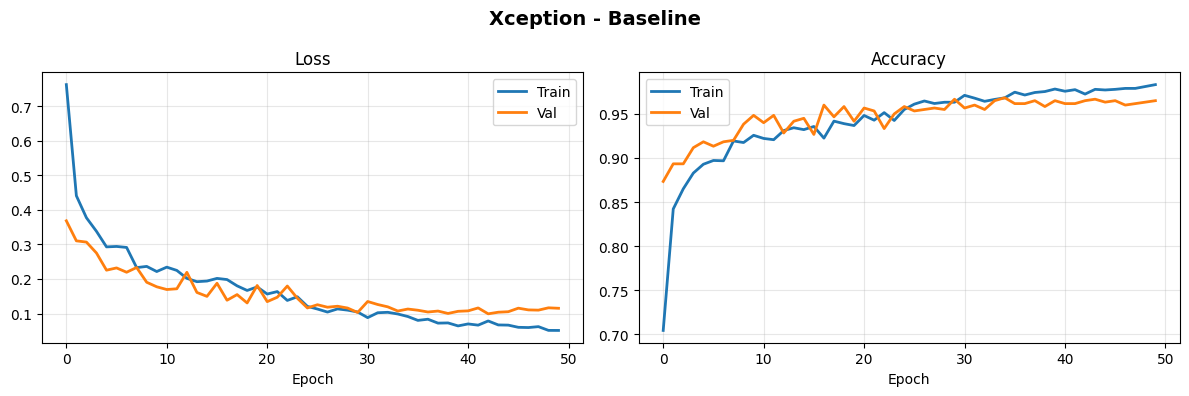

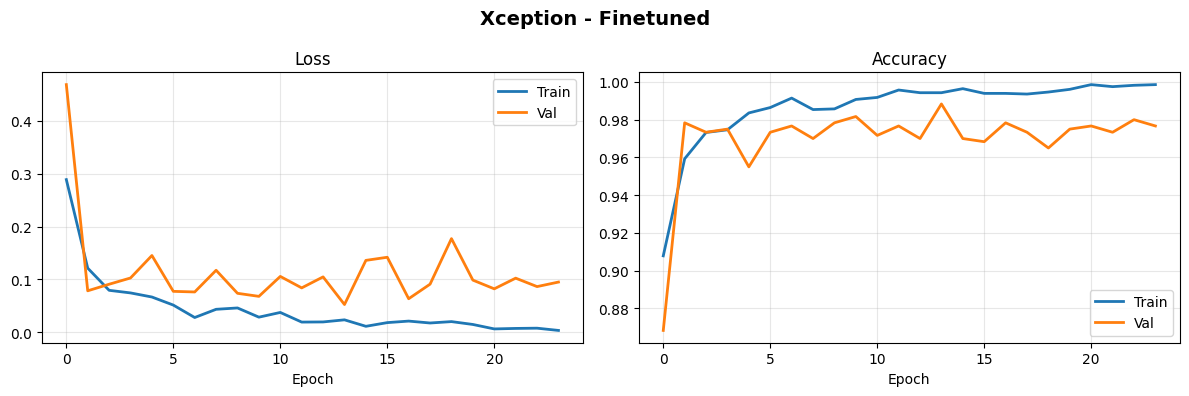

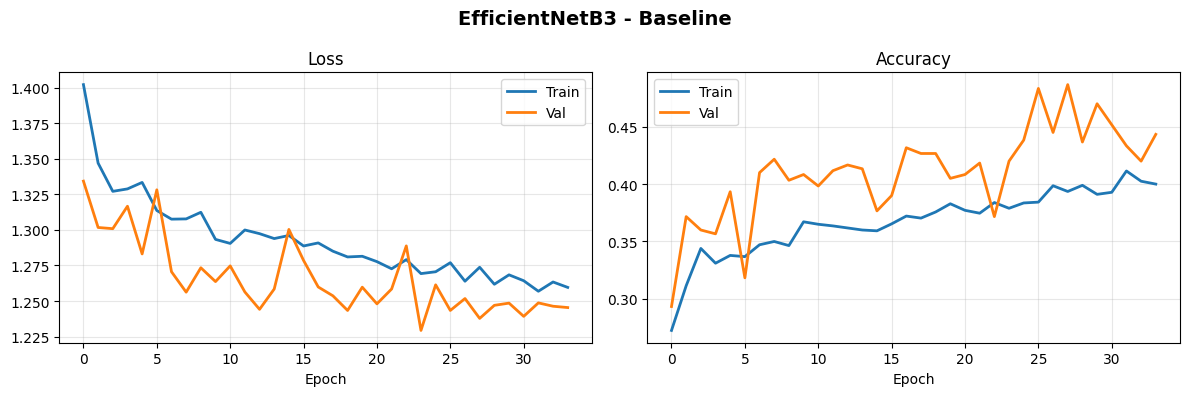

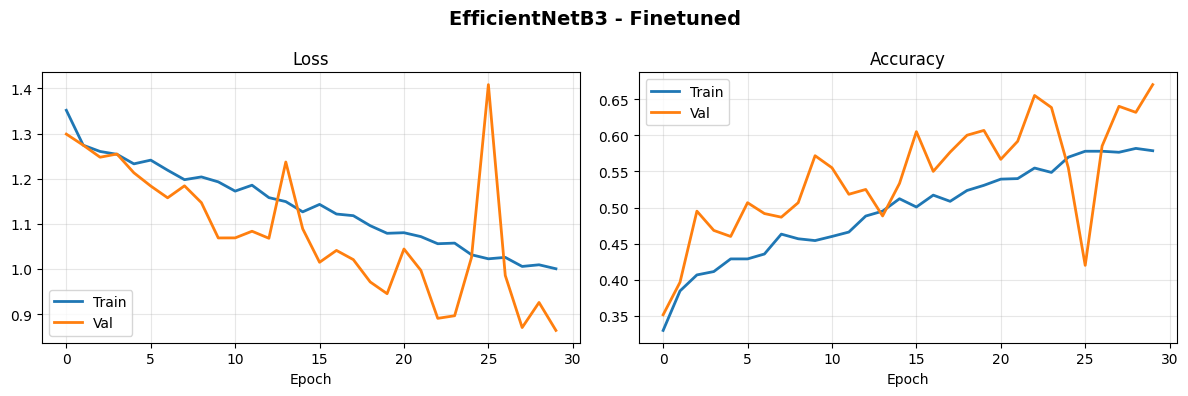

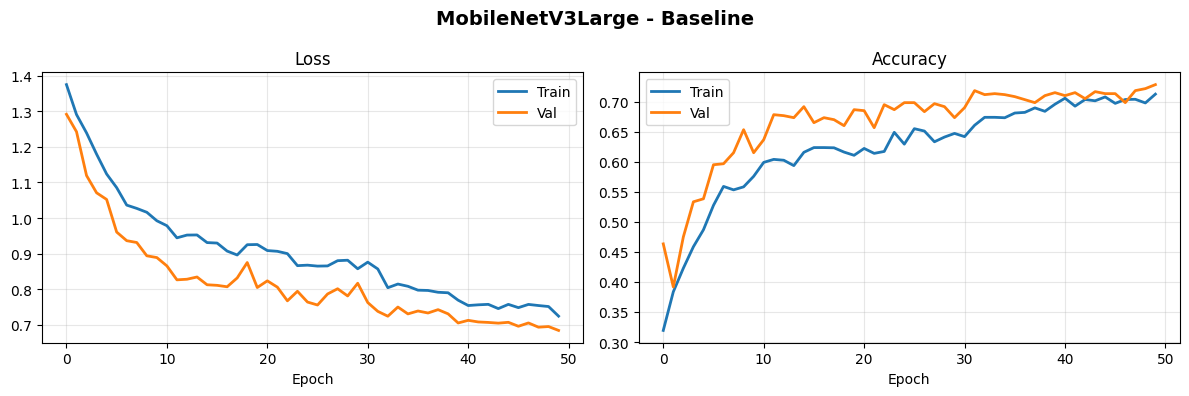

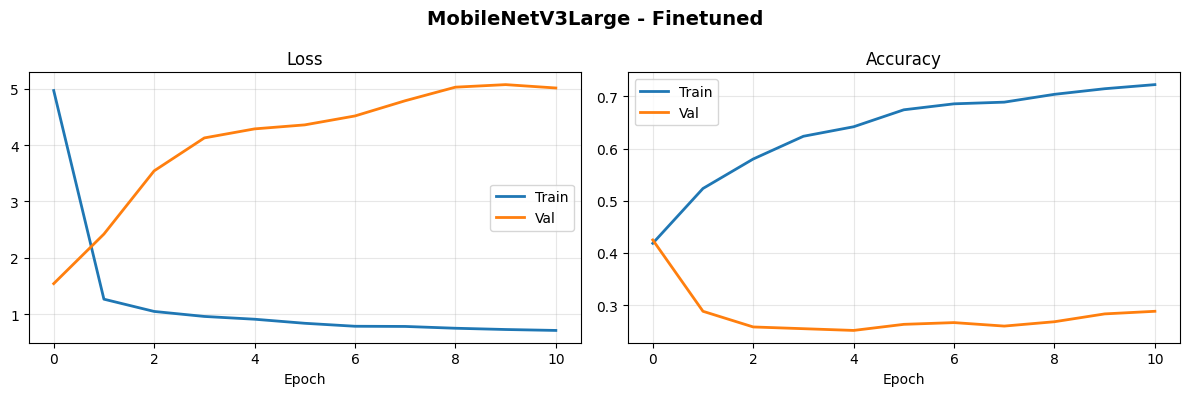

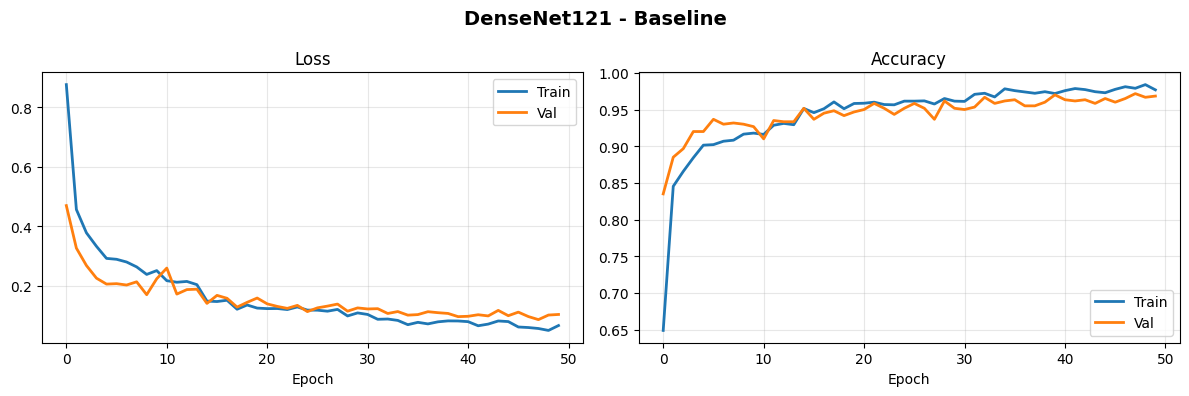

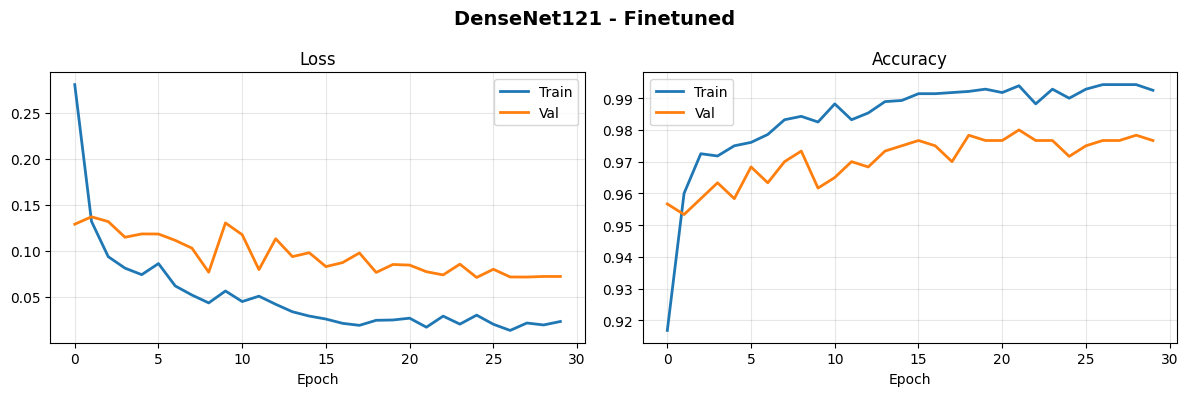

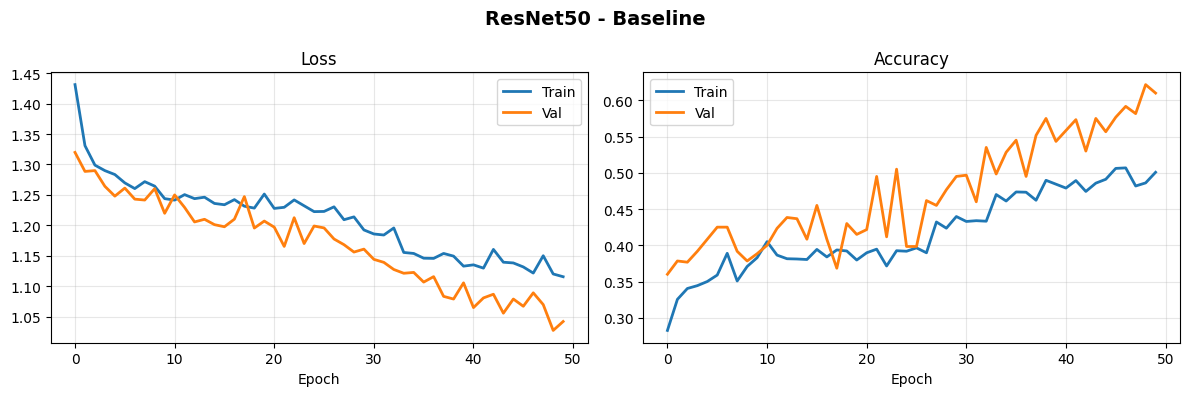

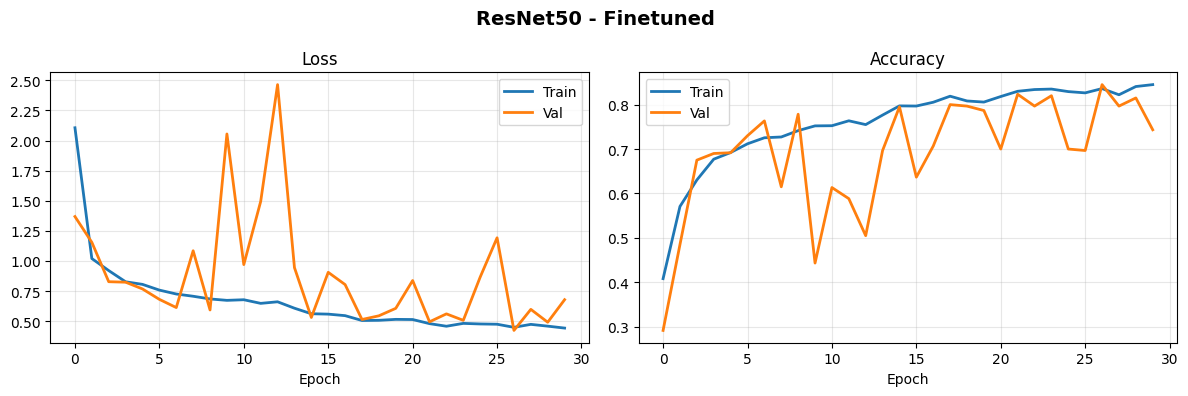

In [ ]:
for model_name in config.MODELS.keys():
    plot_training_history(model_name, 'baseline')
    plot_training_history(model_name, 'finetuned')

Metrics comparison

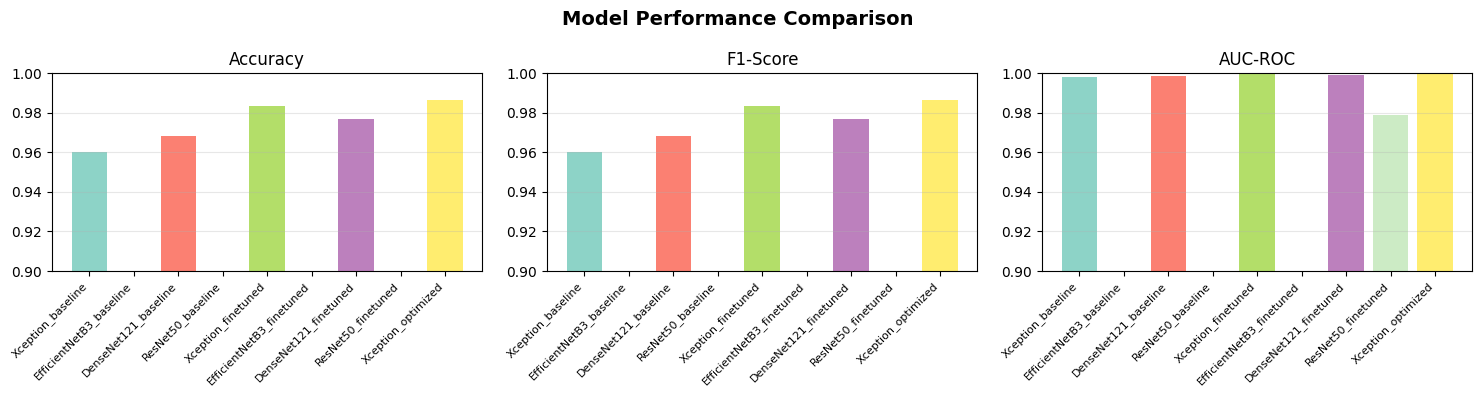

In [ ]:
model_names = list(evaluation_results.keys())
accuracies = [evaluation_results[m]['accuracy'] for m in model_names]
f1_scores = [evaluation_results[m]['f1_weighted'] for m in model_names]
auc_scores = [evaluation_results[m]['auc_macro'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

axes[0].bar(range(len(model_names)), accuracies, color=plt.cm.Set3(np.linspace(0, 1, len(model_names))))
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Accuracy')
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(model_names)), f1_scores, color=plt.cm.Set3(np.linspace(0, 1, len(model_names))))
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('F1-Score')
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(len(model_names)), auc_scores, color=plt.cm.Set3(np.linspace(0, 1, len(model_names))))
axes[2].set_xticks(range(len(model_names)))
axes[2].set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
axes[2].set_title('AUC-ROC')
axes[2].set_ylim([0.9, 1.0])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_PATH, 'plots', 'metrics_comparison.png'), dpi=150)
plt.show()

Confusion matrices

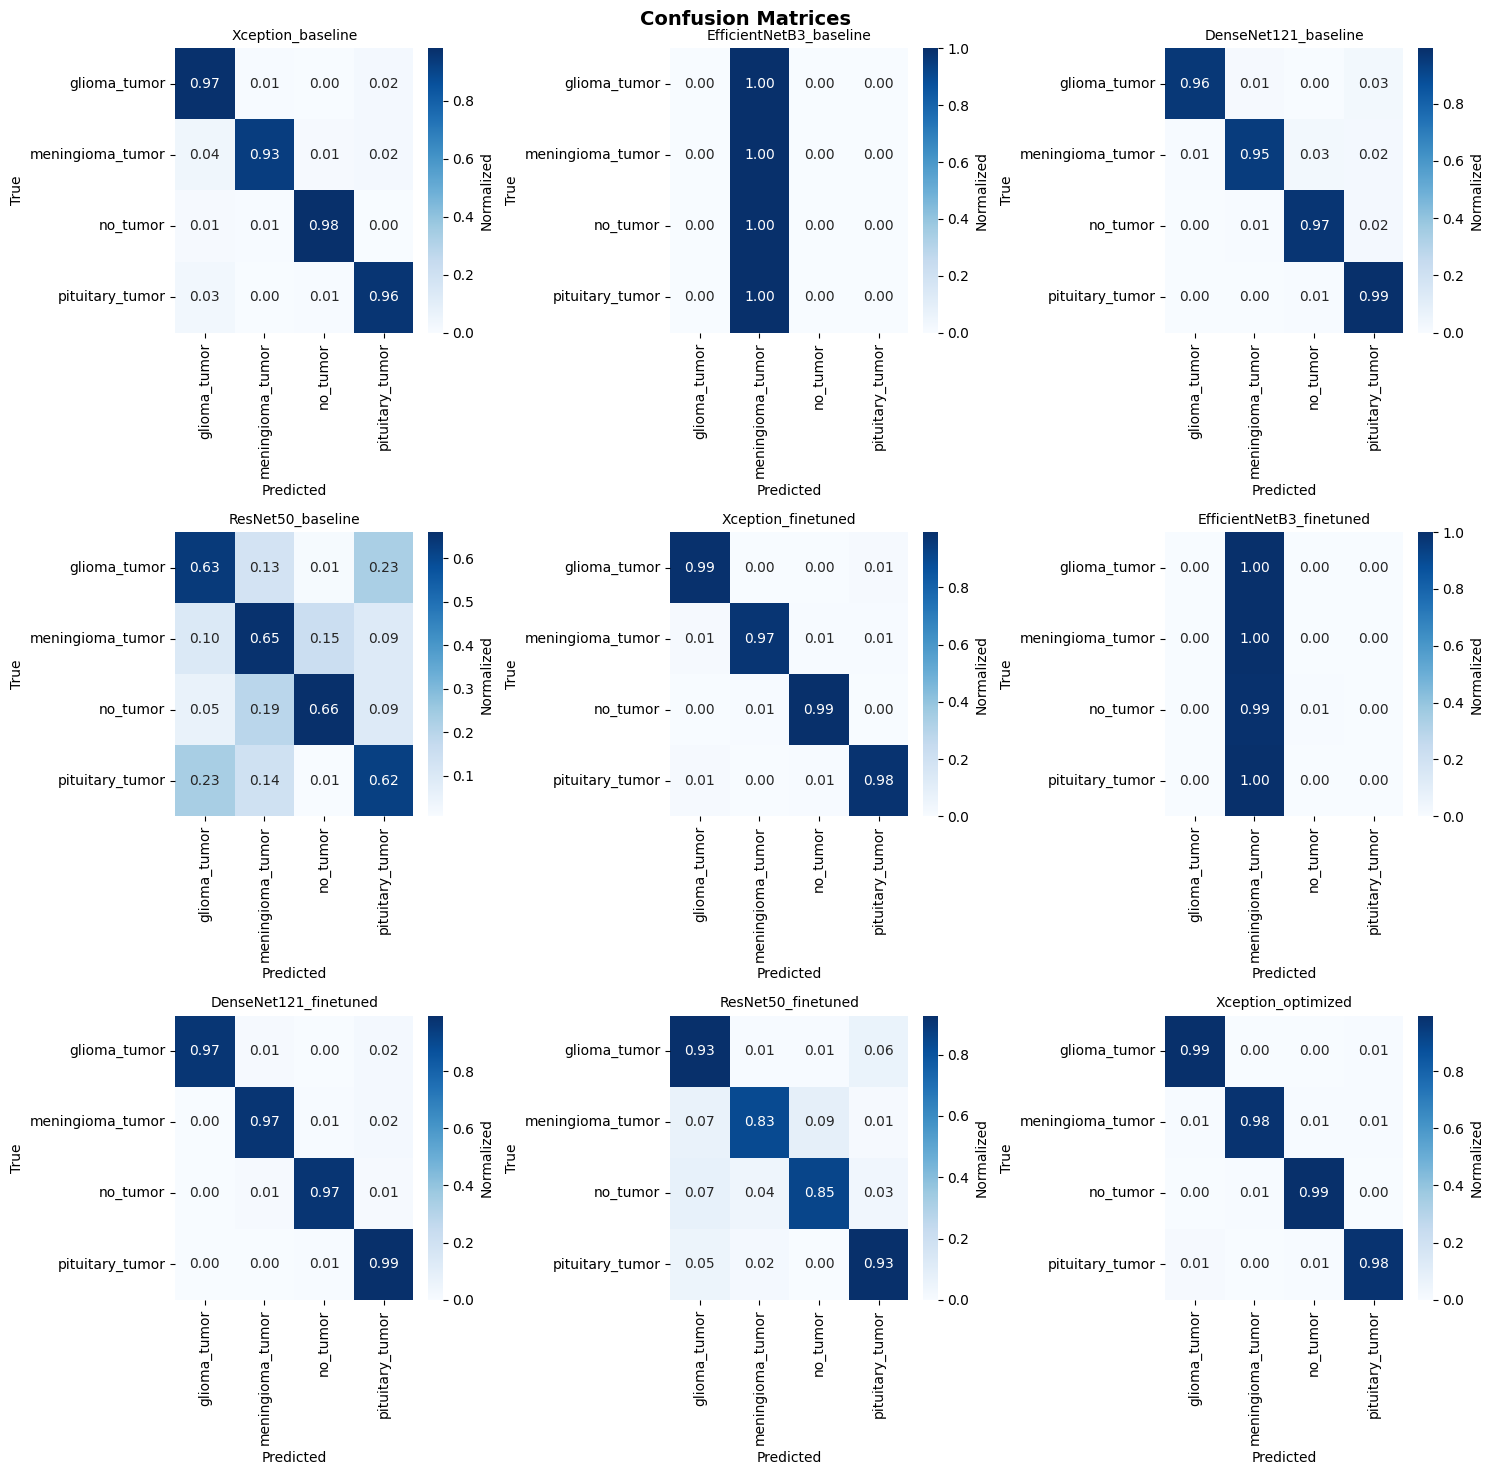

In [ ]:
n_models = len(evaluation_results)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

axes = axes.flatten()

for idx, (model_key, results) in enumerate(evaluation_results.items()):
    cm = np.array(results['confusion_matrix'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
               xticklabels=config.CLASSES, yticklabels=config.CLASSES,
               ax=axes[idx], cbar_kws={'label': 'Normalized'})
    axes[idx].set_title(model_key, fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_PATH, 'plots', 'confusion_matrices.png'), dpi=150)
plt.show()

#Phase 7: Error Analysis

##### **7.1 Misclassification Investigation**
- Extract misclassified samples
- Visualize worst predictions
- Analyze common failure patterns
- Identify challenging cases

##### **7.2 Class-Specific Analysis**
- Per-class sensitivity and specificity
- Identify which classes are confused
- Class-wise precision-recall trade-offs

##### **7.3 Gradient-based Interpretability**
- Grad-CAM visualizations for key predictions
- Show which regions influence decisions
- Validate model attention on tumor regions



In [ ]:
for model_key in evaluation_results.keys():
    results = evaluation_results[model_key]
    y_true = np.array(results['y_true'])
    y_pred = np.array(results['y_pred'])

    misclassified_idx = np.where(y_true != y_pred)[0]
    error_rate = len(misclassified_idx) / len(y_true) * 100

    print(f"\n{model_key}: {len(misclassified_idx)} errors ({error_rate:.2f}%)")


Xception_baseline: 24 errors (4.00%)

EfficientNetB3_baseline: 450 errors (75.00%)

DenseNet121_baseline: 19 errors (3.17%)

ResNet50_baseline: 215 errors (35.83%)

Xception_finetuned: 10 errors (1.67%)

EfficientNetB3_finetuned: 449 errors (74.83%)

DenseNet121_finetuned: 14 errors (2.33%)

ResNet50_finetuned: 69 errors (11.50%)

Xception_optimized: 8 errors (1.33%)


#Phase 9: Final Ranking

In [ ]:
ranking_data = []
for model_key, results in evaluation_results.items():
    ranking_data.append({
        'Model': model_key,
        'Accuracy': results['accuracy'],
        'Precision': results['precision_weighted'],
        'Recall': results['recall_weighted'],
        'F1-Score': results['f1_weighted'],
        'AUC-ROC': results['auc_macro'],
        'Kappa': results['cohen_kappa'],
        'Inference (ms)': results['inference_time_ms'],
        'Size (MB)': results['model_size_mb']
    })

ranking_df = pd.DataFrame(ranking_data)
ranking_df = ranking_df.sort_values(['Accuracy', 'F1-Score'], ascending=False)
ranking_df.insert(0, 'Rank', range(1, len(ranking_df) + 1))

ranking_df.to_csv(os.path.join(config.OUTPUT_PATH, 'results', 'final_ranking.csv'), index=False)

print("\n FINAL MODEL RANKING:")
print("*"*120)
print(ranking_df.to_string(index=False))
print("*"*120)

best_model = ranking_df.iloc[0]
print(f"\n BEST MODEL: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   AUC-ROC: {best_model['AUC-ROC']:.4f}")
print(f"   Recall: {best_model['Recall']:.4f}")

print(f" Results saved to: {config.OUTPUT_PATH}")


 FINAL MODEL RANKING:
************************************************************************************************************************
 Rank                    Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC    Kappa  Inference (ms)  Size (MB)
    1       Xception_optimized  0.986667   0.986710 0.986667  0.986661 0.999759 0.982222      126.869909 118.265419
    2       Xception_finetuned  0.983333   0.983409 0.983333  0.983333 0.999715 0.977778      131.971389 154.514595
    3    DenseNet121_finetuned  0.976667   0.977216 0.976667  0.976733 0.999278 0.968889      375.811271  39.304253
    4     DenseNet121_baseline  0.968333   0.969102 0.968333  0.968371 0.998811 0.957778      379.075937  31.062897
    5        Xception_baseline  0.960000   0.961014 0.960000  0.960078 0.998022 0.946667      157.510690  86.276497
    6       ResNet50_finetuned  0.885000   0.887872 0.885000  0.884899 0.978815 0.846667      132.037997 207.033516
    7        ResNet50_baseline  0.641667   0